# Seeding Strategy Comparison Across Topologies

Compares how different initial seeding strategies affect simplicial contagion
dynamics across multiple graph topologies (RSC, BA, SBM). For each topology,
reproduces Figure 3a (steady-state sweep) and Figure 3b (bistability
trajectories) for each seeding strategy.

Mean-field analytical curves are dropped here since they are only valid for
homogeneous topologies (RSC).

In [1]:
import sys
sys.path.insert(0, '..')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

from scm import RSCGenerator, BAGenerator, SBMGenerator, SCMSimulator
from scm import RandomSeeding, HighDegreeSeeding, HighSimplexSeeding
from scm.analysis import steady_state_rho

STRATEGIES = [
    ("Random", RandomSeeding),
    ("High Degree", HighDegreeSeeding),
    ("High 2-Simplex", HighSimplexSeeding),
]

## Shared parameters

In [3]:
# --- Simulation parameters (shared across topologies) ---
N = 2000
K_AVG_TARGET = 20
K_D_AVG_TARGET = 6
MU = 0.1

T_MAX_3A = 2000
T_AVG = 100
RHO_0_3A = 0.4
LAMBDA_VALS = np.linspace(0.0, 2.5, 30)
LAMBDA_DELTAS = [0.0, 0.8, 2.5]

T_MAX_3B = 500
LAM_3B = 0.75
LAM_D_3B = 2.5
N_3B = 4000
RHO_0_VALS_3B = np.concatenate((
    np.linspace(0.02, 0.18, 8),
    np.linspace(0.22, 0.95, 15)
))

SEED_3A = 2025
SEED_3B = 2026

## Topology configurations

Each topology is defined by a pair of factory functions (one for the 3a network
size, one for the 3b network size). Factories are invoked lazily so seeding
and generation happen in a controlled order.

Parameters are tuned so realized `k_avg` and `k_delta_avg` land in the same
ballpark as the RSC target (~20, ~6). Exact values vary with topology because
triangles always add any missing constituent edges (RSC convention), which
inflates `k_avg` when the base graph is sparse. The simulation rescales
`beta` using the *realized* degrees so lambda sweeps remain comparable.

In [13]:
# --- BA defaults ---
BA_M = 5
BA_M_DELTA = 2

# --- SBM defaults (auto-computed, 4 equal communities) ---
SBM_K = 4
SBM_INTRA_FRAC = 0.8          # fraction of edge-degree from intra-community
SBM_KAVG_EDGE = 14            # edge-only k_avg target (realized lands ~20)


def make_sbm_block_matrix(N=None, K=SBM_K, intra_frac=SBM_INTRA_FRAC,
                          k_avg_edge=SBM_KAVG_EDGE, values=None):
    """Build the KxK block matrix for SBMGenerator.

    If `values` (list of lists) is provided, returns it as a float array.
    Otherwise auto-computes a symmetric matrix with diagonal p_intra and
    off-diagonal p_inter derived from N, K, intra_frac, k_avg_edge.
    """
    if values is not None:
        arr = np.asarray(values, dtype=float)
        if arr.ndim != 2 or arr.shape[0] != arr.shape[1]:
            raise ValueError("block_matrix values must be a square list of lists")
        return arr
    p_intra = intra_frac * k_avg_edge * K / N
    p_inter = (1 - intra_frac) * k_avg_edge * K / (N * (K - 1))
    bm = np.full((K, K), p_inter)
    np.fill_diagonal(bm, p_intra)
    return bm


def make_sbm_triangle_kwarg(N=None, K=SBM_K, k_delta_avg=K_D_AVG_TARGET,
                             values=None):
    """Return a kwarg dict to splat into SBMGenerator(..., **result).

    `values` can be:
      - None: auto-compute intra-only probs from (N, K, k_delta_avg).
      - length-K list: per-community intra-community probs
        -> {"triangle_block_probs": [...]}.
      - KxKxK list of lists of lists: full tensor over block triples
        -> {"triangle_block_tensor": [[[...]]]}.
    """
    if values is None:
        p_tri = k_delta_avg * 2 * K**2 / N**2
        return {"triangle_block_probs": [p_tri] * K}
    arr = np.asarray(values, dtype=float)
    if arr.ndim == 1:
        if arr.shape[0] != K:
            raise ValueError(f"1D triangle values must have length {K}")
        return {"triangle_block_probs": arr.tolist()}
    if arr.ndim == 3:
        if arr.shape != (K, K, K):
            raise ValueError(
                f"3D triangle values must have shape ({K},{K},{K})"
            )
        return {"triangle_block_tensor": arr}
    raise ValueError("triangle values must be 1D (length K) or 3D ((K,K,K))")


def equal_community_sizes(N, K=SBM_K):
    base = N // K
    sizes = [base] * K
    sizes[-1] += N - base * K
    return sizes


# --- Manual SBM instance ---
# Edit the lists below to try different configurations. The 3b variant scales
# community sizes up by N_3B/N and scales block / triangle probabilities down
# by the inverse factors so that realized k_avg and k_delta_avg are preserved.
SBM_MANUAL_K = 5
SBM_MANUAL_SIZES_3A = [800, 600, 400, 180, 20]
SBM_MANUAL_BLOCK_3A = [
    [0.020, 0.003, 0.001, 0.000, 0.3],
    [0.003, 0.025, 0.004, 0.001, 0.3],
    [0.001, 0.004, 0.035, 0.005, 0.3],
    [0.000, 0.001, 0.005, 0.060, 0.3],
    [0.3, 0.3, 0.3, 0.3, 0.3],
]
# Intra-community triangle probs (length K). Replace with a KxKxK list of
# lists of lists here AND in SBM_MANUAL_TRI_3B if you want cross-community
# triangles; make_sbm_triangle_kwarg will dispatch on shape automatically.
SBM_MANUAL_TRI_3A = [3e-5, 4e-5, 6e-5, 1e-4, 1e-3]

_manual_scale = N_3B / N
SBM_MANUAL_SIZES_3B = [int(round(s * _manual_scale)) for s in SBM_MANUAL_SIZES_3A]
SBM_MANUAL_BLOCK_3B = (
    np.asarray(SBM_MANUAL_BLOCK_3A) / _manual_scale
).tolist()
SBM_MANUAL_TRI_3B = (
    np.asarray(SBM_MANUAL_TRI_3A) / (_manual_scale ** 2)
).tolist()


TOPOLOGY_CONFIGS = [
    {
        "name": "RSC",
        "make_3a": lambda: RSCGenerator(
            k_avg=K_AVG_TARGET, k_delta_avg=K_D_AVG_TARGET, N=N),
        "make_3b": lambda: RSCGenerator(
            k_avg=K_AVG_TARGET, k_delta_avg=K_D_AVG_TARGET, N=N_3B),
    },
    {
        "name": "BA",
        "make_3a": lambda: BAGenerator(
            m=BA_M, m_delta=BA_M_DELTA, N=N),
        "make_3b": lambda: BAGenerator(
            m=BA_M, m_delta=BA_M_DELTA, N=N_3B),
    },
    {
        "name": "SBM",
        "make_3a": lambda: SBMGenerator(
            community_sizes=equal_community_sizes(N),
            block_matrix=make_sbm_block_matrix(N=N),
            **make_sbm_triangle_kwarg(N=N)),
        "make_3b": lambda: SBMGenerator(
            community_sizes=equal_community_sizes(N_3B),
            block_matrix=make_sbm_block_matrix(N=N_3B),
            **make_sbm_triangle_kwarg(N=N_3B)),
    },
    {
        "name": "SBM-Manual",
        "make_3a": lambda: SBMGenerator(
            community_sizes=SBM_MANUAL_SIZES_3A,
            block_matrix=make_sbm_block_matrix(values=SBM_MANUAL_BLOCK_3A),
            **make_sbm_triangle_kwarg(
                K=SBM_MANUAL_K, values=SBM_MANUAL_TRI_3A)),
        "make_3b": lambda: SBMGenerator(
            community_sizes=SBM_MANUAL_SIZES_3B,
            block_matrix=make_sbm_block_matrix(values=SBM_MANUAL_BLOCK_3B),
            **make_sbm_triangle_kwarg(
                K=SBM_MANUAL_K, values=SBM_MANUAL_TRI_3B)),
    },
]


## Simulation helpers

In [14]:
def run_steady_state(seeder_cls, links, triangles, N_graph,
                     k_avg, k_d_avg, lam_d,
                     mu=MU, rho_0=RHO_0_3A, t_max=T_MAX_3A, t_avg=T_AVG,
                     lambda_vals=LAMBDA_VALS):
    """Sweep lambda for a fixed lambda_delta; return steady-state rho* array.
    beta and beta_delta are rescaled using *realized* graph degrees."""
    rho_stars = []
    beta_d = (lam_d * mu) / k_d_avg

    for lam in lambda_vals:
        beta = (lam * mu) / k_avg
        seeder = seeder_cls(N_graph, rho_0, links=links, triangles=triangles)
        initial_infected = seeder.seed()

        sim = SCMSimulator(
            links=links, triangles=triangles,
            initial_infected=initial_infected,
            beta=beta, beta_delta=beta_d, mu=mu,
        )
        rho_history = sim.run(t_max)
        rho_stars.append(steady_state_rho(rho_history, t_avg))

    return np.array(rho_stars)


def run_trajectories(seeder_cls, links, triangles, N_graph,
                     k_avg, k_d_avg,
                     lam=LAM_3B, lam_d=LAM_D_3B,
                     mu=MU, t_max=T_MAX_3B, rho_0_vals=RHO_0_VALS_3B):
    """Sweep rho_0 at fixed lambda/lambda_delta; return list of (rho_0, history)."""
    beta = (lam * mu) / k_avg
    beta_d = (lam_d * mu) / k_d_avg
    histories = []

    for rho_0 in rho_0_vals:
        seeder = seeder_cls(N_graph, rho_0, links=links, triangles=triangles)
        initial_infected = seeder.seed()

        sim = SCMSimulator(
            links=links, triangles=triangles,
            initial_infected=initial_infected,
            beta=beta, beta_delta=beta_d, mu=mu,
        )
        rho_history = sim.run(t_max)
        histories.append((rho_0, rho_history))

    return histories

## Generate topologies

For each topology, build the 3a graph (N=2000) and the 3b graph (N=4000).
Realized `k_avg` and `k_delta_avg` are reported per graph and reused downstream
for rescaling.

In [15]:
topologies = {}
for config in TOPOLOGY_CONFIGS:
    name = config["name"]
    print(f"\n--- Generating {name} (3a) ---")
    gen_3a = config["make_3a"]()
    links_3a, triangles_3a = gen_3a.generate(seed=SEED_3A)

    print(f"\n--- Generating {name} (3b) ---")
    gen_3b = config["make_3b"]()
    links_3b, triangles_3b = gen_3b.generate(seed=SEED_3B)

    topologies[name] = {
        "3a": {
            "links": links_3a, "triangles": triangles_3a,
            "N": gen_3a.N, "k_avg": gen_3a.k_avg,
            "k_d_avg": gen_3a.k_delta_avg,
        },
        "3b": {
            "links": links_3b, "triangles": triangles_3b,
            "N": gen_3b.N, "k_avg": gen_3b.k_avg,
            "k_d_avg": gen_3b.k_delta_avg,
        },
    }



--- Generating RSC (3a) ---
Sampling edges with p_1 = 0.00402617
Edges sampled: 7913/7913
Sampling triangles with p_delta = 0.00000300
Triangles sampled: 4035/4035
Realized k_avg = 19.95, k_delta_avg = 6.05

--- Generating RSC (3b) ---
Sampling edges with p_1 = 0.00200652
Edges sampled: 16015/16015
Sampling triangles with p_delta = 0.00000075
Triangles sampled: 7933/7933
Realized k_avg = 19.86, k_delta_avg = 5.95

--- Generating BA (3a) ---
BA nodes added: 2000/2000
Realized k_avg = 21.13, k_delta_avg = 5.94

--- Generating BA (3b) ---
BA nodes added: 4000/4000
Realized k_avg = 21.34, k_delta_avg = 5.93

--- Generating SBM (3a) ---
Sampling edges per block-pair
SBM edges sampled (through block 3,3): 13799
Sampling triangles per block-triple
SBM triangles sampled (through block 3,3,3): 4010
Realized k_avg = 25.47, k_delta_avg = 6.01

--- Generating SBM (3b) ---
Sampling edges per block-pair
SBM edges sampled (through block 3,3): 27927
Sampling triangles per block-triple
SBM triangles s

## Run simulations

For each topology × strategy, run both the steady-state sweep (3a) and the
bistability trajectories (3b).

In [16]:
all_results = {}

for config in TOPOLOGY_CONFIGS:
    name = config["name"]
    topo = topologies[name]
    print(f"\n=== Topology: {name} ===")

    topo_results = {}
    for strat_name, strat_cls in STRATEGIES:
        print(f"  [{strat_name}]")

        ss = {}
        for ld in LAMBDA_DELTAS:
            print(f"    3a: lambda_delta={ld} ...")
            ss[ld] = run_steady_state(
                strat_cls,
                links=topo["3a"]["links"],
                triangles=topo["3a"]["triangles"],
                N_graph=topo["3a"]["N"],
                k_avg=topo["3a"]["k_avg"],
                k_d_avg=topo["3a"]["k_d_avg"],
                lam_d=ld,
            )

        print(f"    3b: trajectories ...")
        traj = run_trajectories(
            strat_cls,
            links=topo["3b"]["links"],
            triangles=topo["3b"]["triangles"],
            N_graph=topo["3b"]["N"],
            k_avg=topo["3b"]["k_avg"],
            k_d_avg=topo["3b"]["k_d_avg"],
        )

        topo_results[strat_name] = {"steady_state": ss, "trajectories": traj}

    all_results[name] = topo_results


=== Topology: RSC ===
  [Random]
    3a: lambda_delta=0.0 ...
    3a: lambda_delta=0.8 ...
    3a: lambda_delta=2.5 ...
    3b: trajectories ...
  [High Degree]
    3a: lambda_delta=0.0 ...
    3a: lambda_delta=0.8 ...
    3a: lambda_delta=2.5 ...
    3b: trajectories ...
  [High 2-Simplex]
    3a: lambda_delta=0.0 ...
    3a: lambda_delta=0.8 ...
    3a: lambda_delta=2.5 ...
    3b: trajectories ...

=== Topology: BA ===
  [Random]
    3a: lambda_delta=0.0 ...
    3a: lambda_delta=0.8 ...
    3a: lambda_delta=2.5 ...
    3b: trajectories ...
  [High Degree]
    3a: lambda_delta=0.0 ...
    3a: lambda_delta=0.8 ...
    3a: lambda_delta=2.5 ...
    3b: trajectories ...
  [High 2-Simplex]
    3a: lambda_delta=0.0 ...
    3a: lambda_delta=0.8 ...
    3a: lambda_delta=2.5 ...
    3b: trajectories ...

=== Topology: SBM ===
  [Random]
    3a: lambda_delta=0.0 ...
    3a: lambda_delta=0.8 ...
    3a: lambda_delta=2.5 ...
    3b: trajectories ...
  [High Degree]
    3a: lambda_delta=0.0 ...


## Plot per topology

One figure per topology. Each row is a strategy; left column is Fig 3a
(steady-state rho* vs lambda), right column is Fig 3b (bistability
trajectories). No mean-field analytical curves.

Saved: ../figures/seeding_strategy_comparison_rsc.png


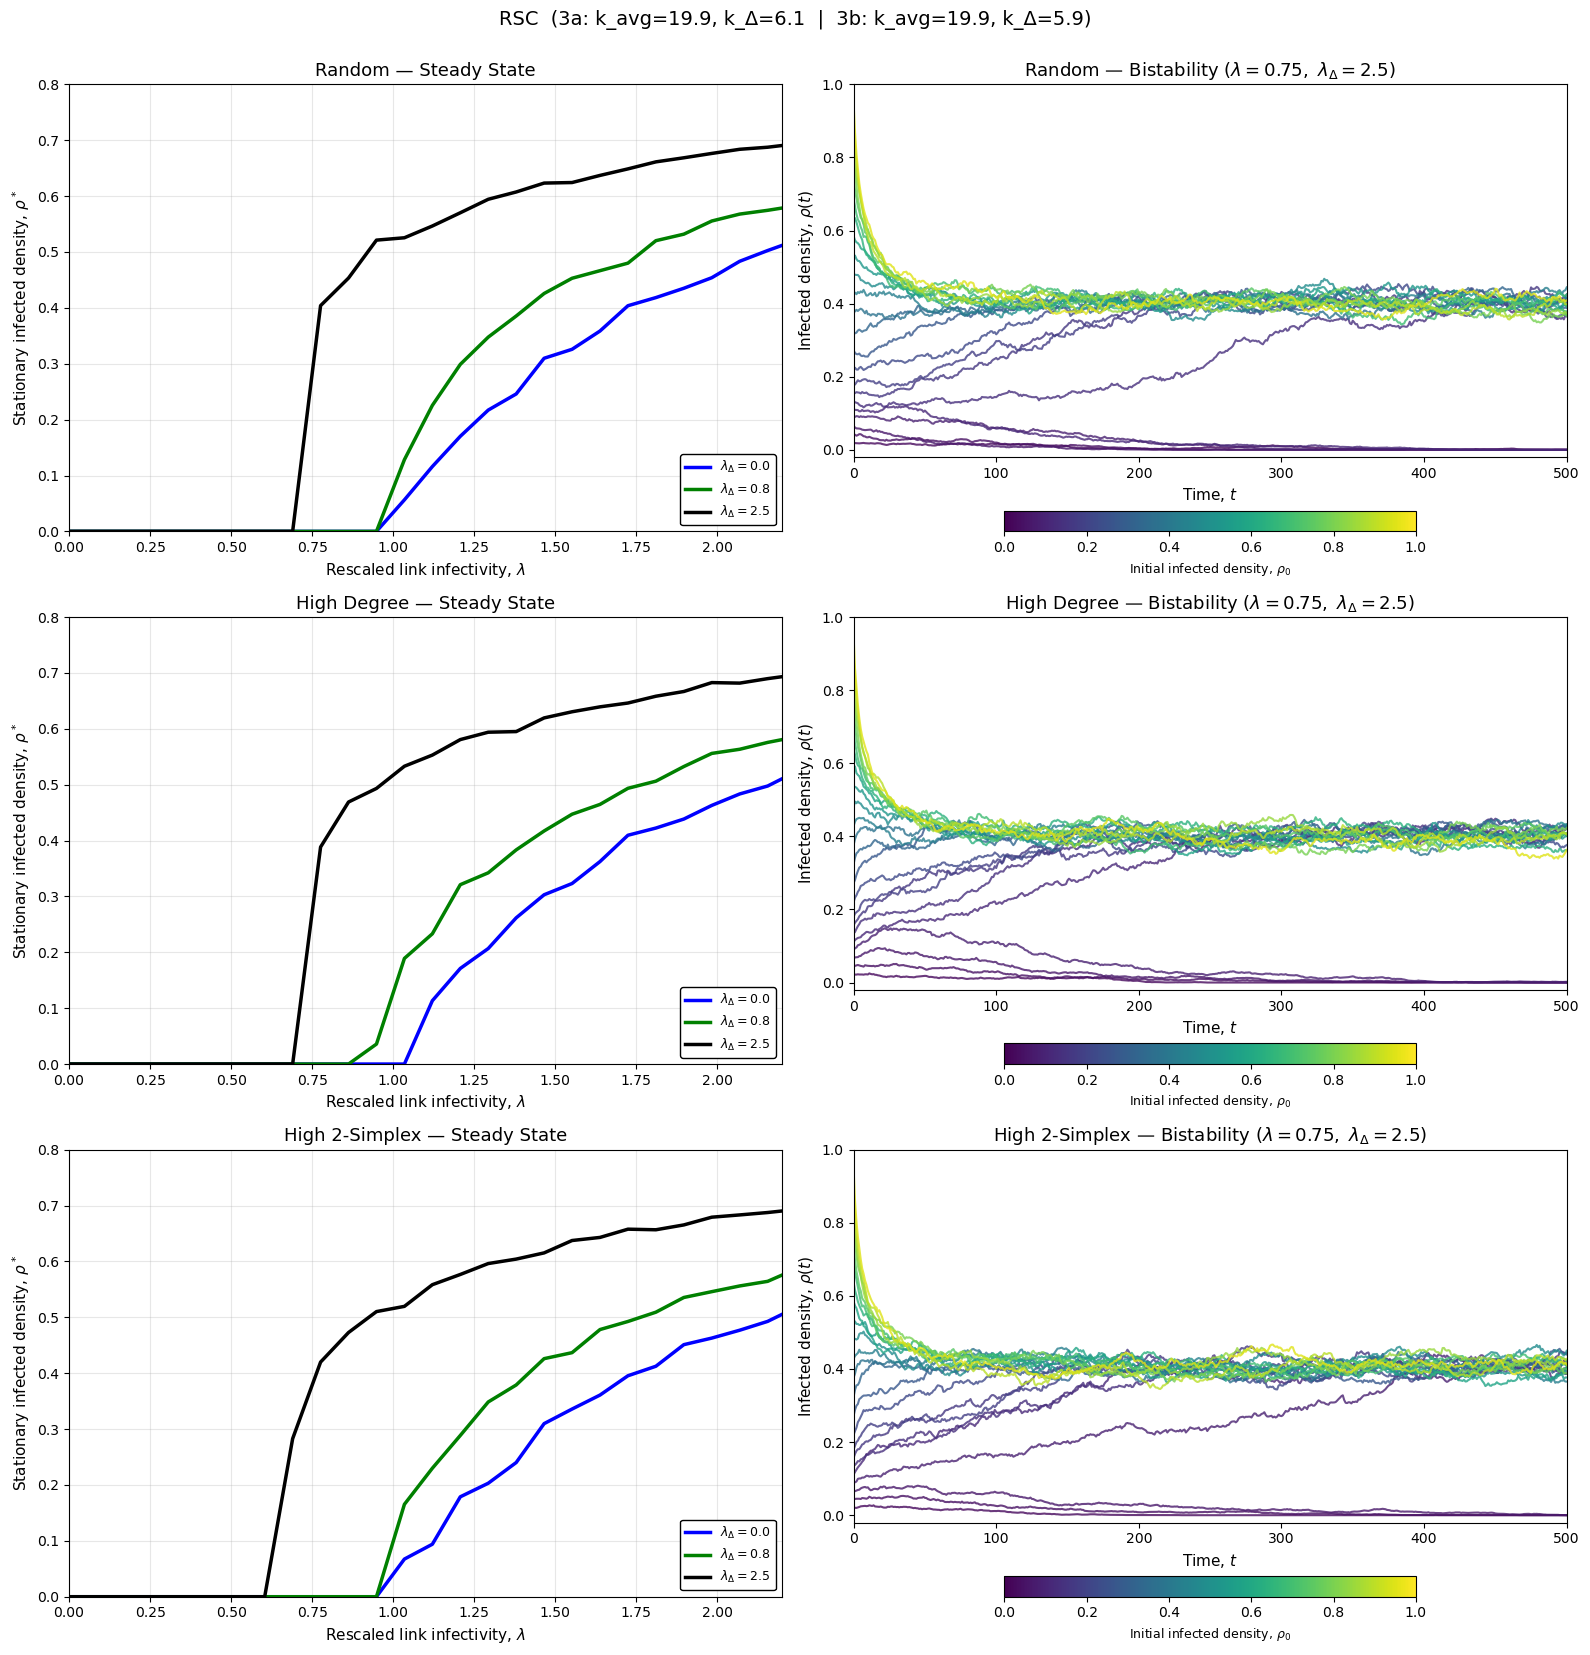

Saved: ../figures/seeding_strategy_comparison_ba.png


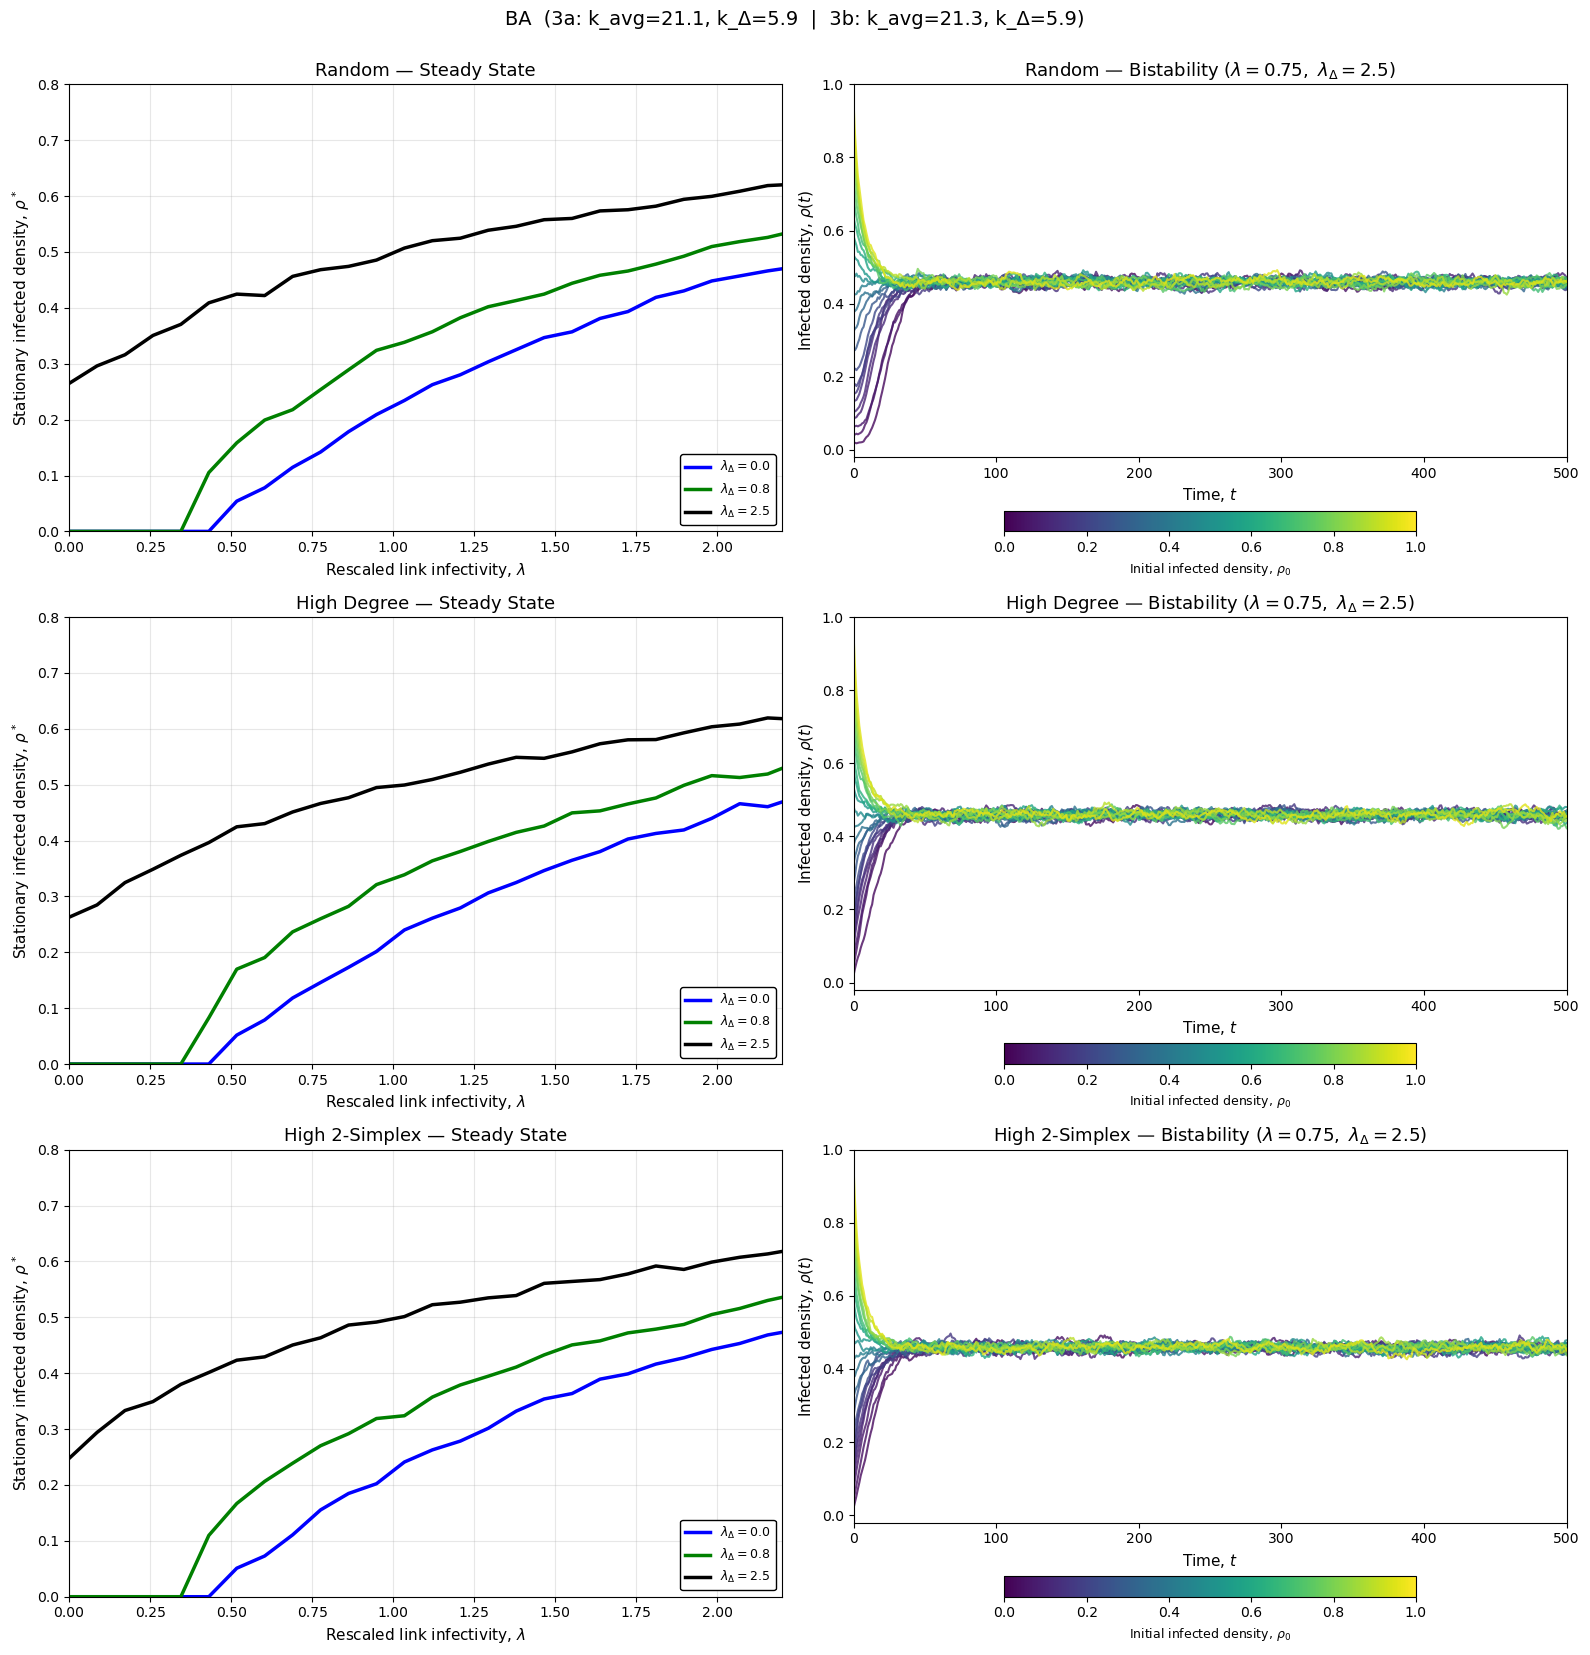

Saved: ../figures/seeding_strategy_comparison_sbm.png


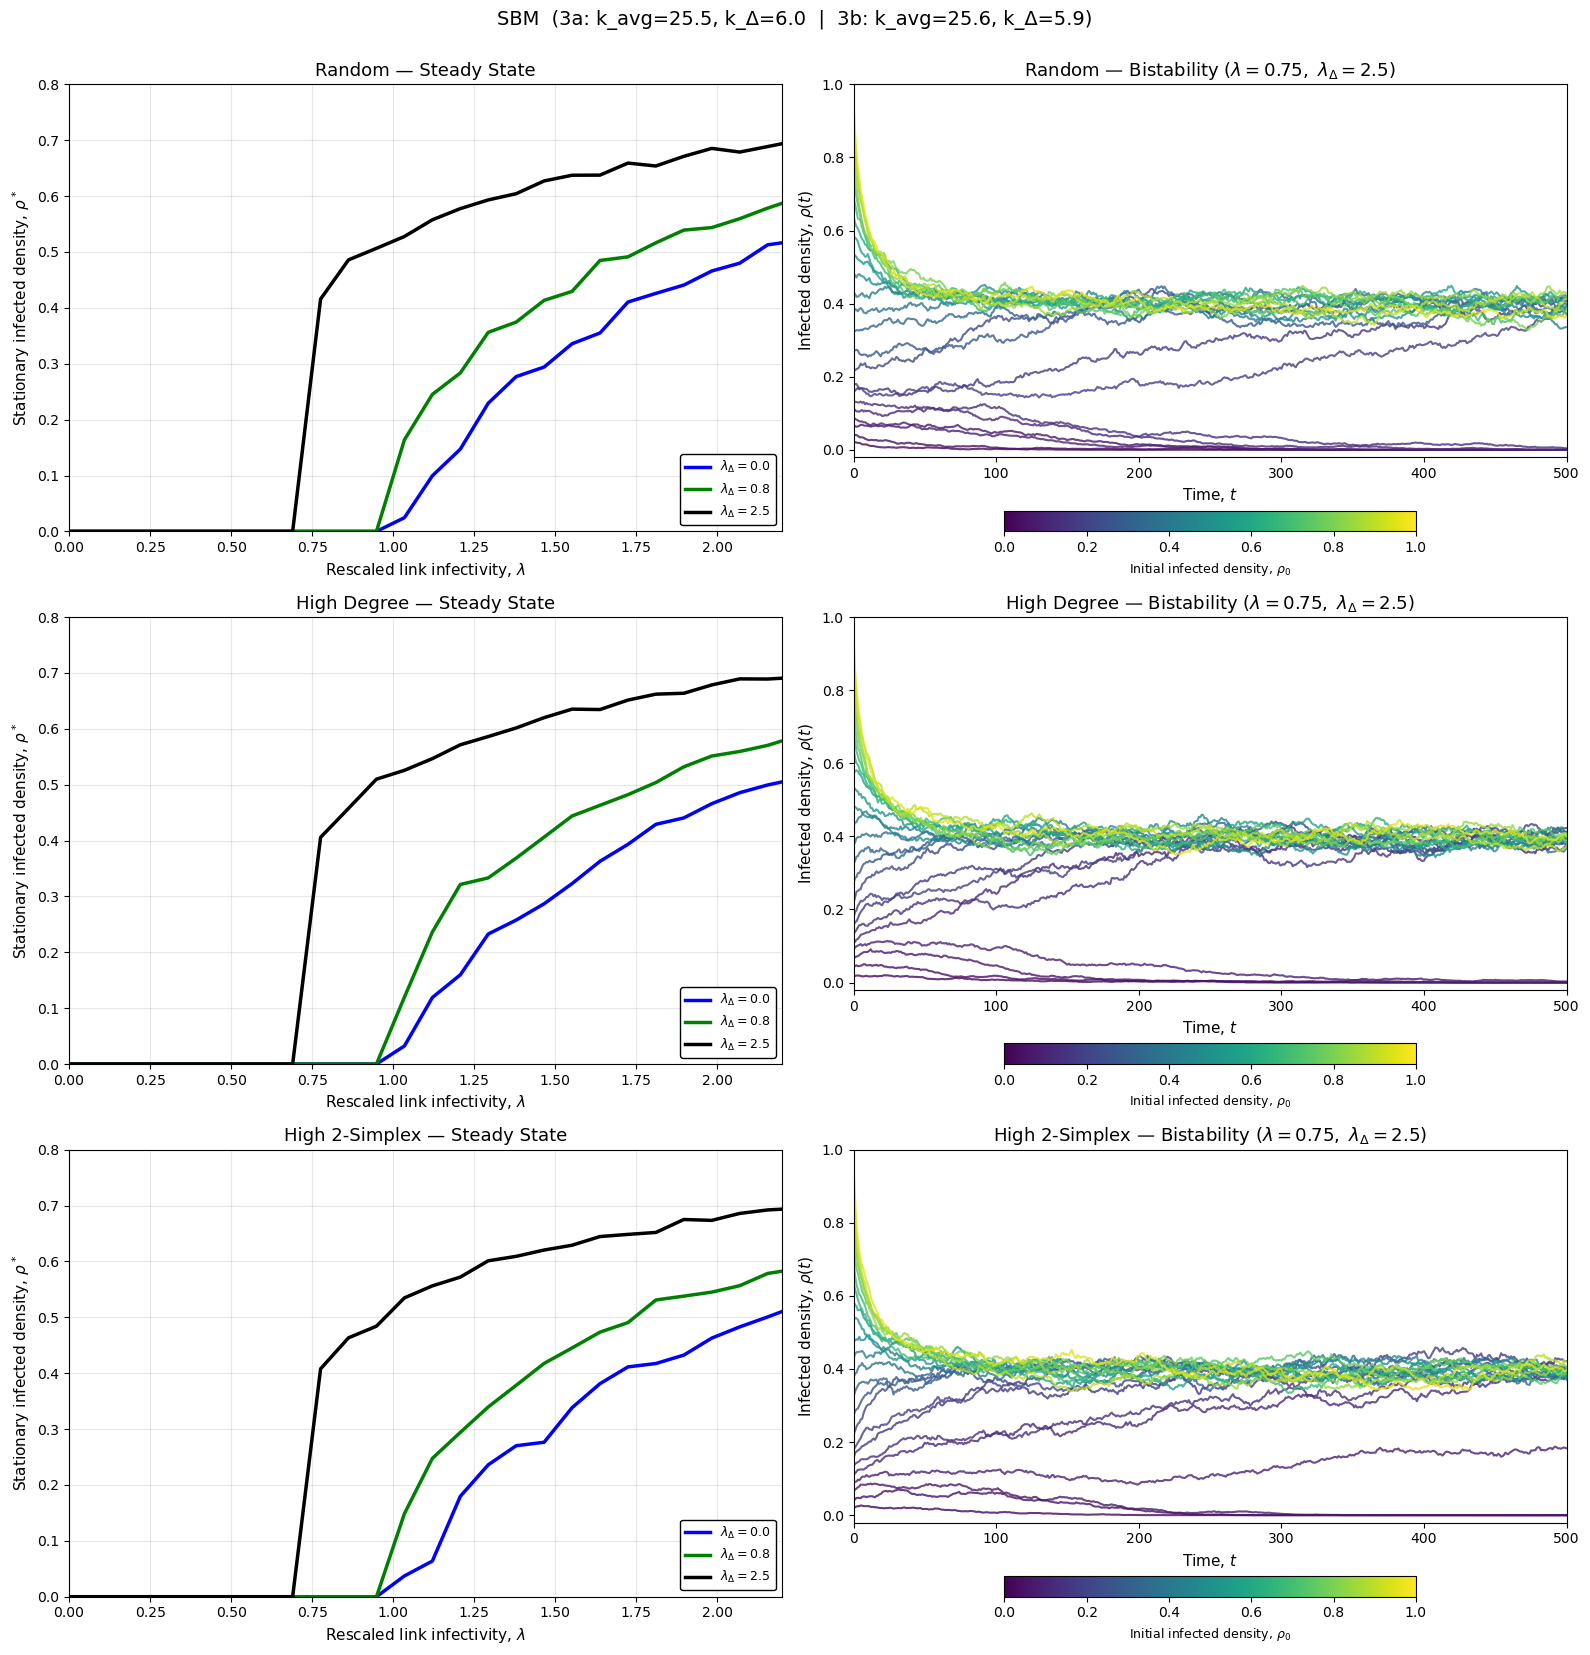

Saved: ../figures/seeding_strategy_comparison_sbm-manual.png


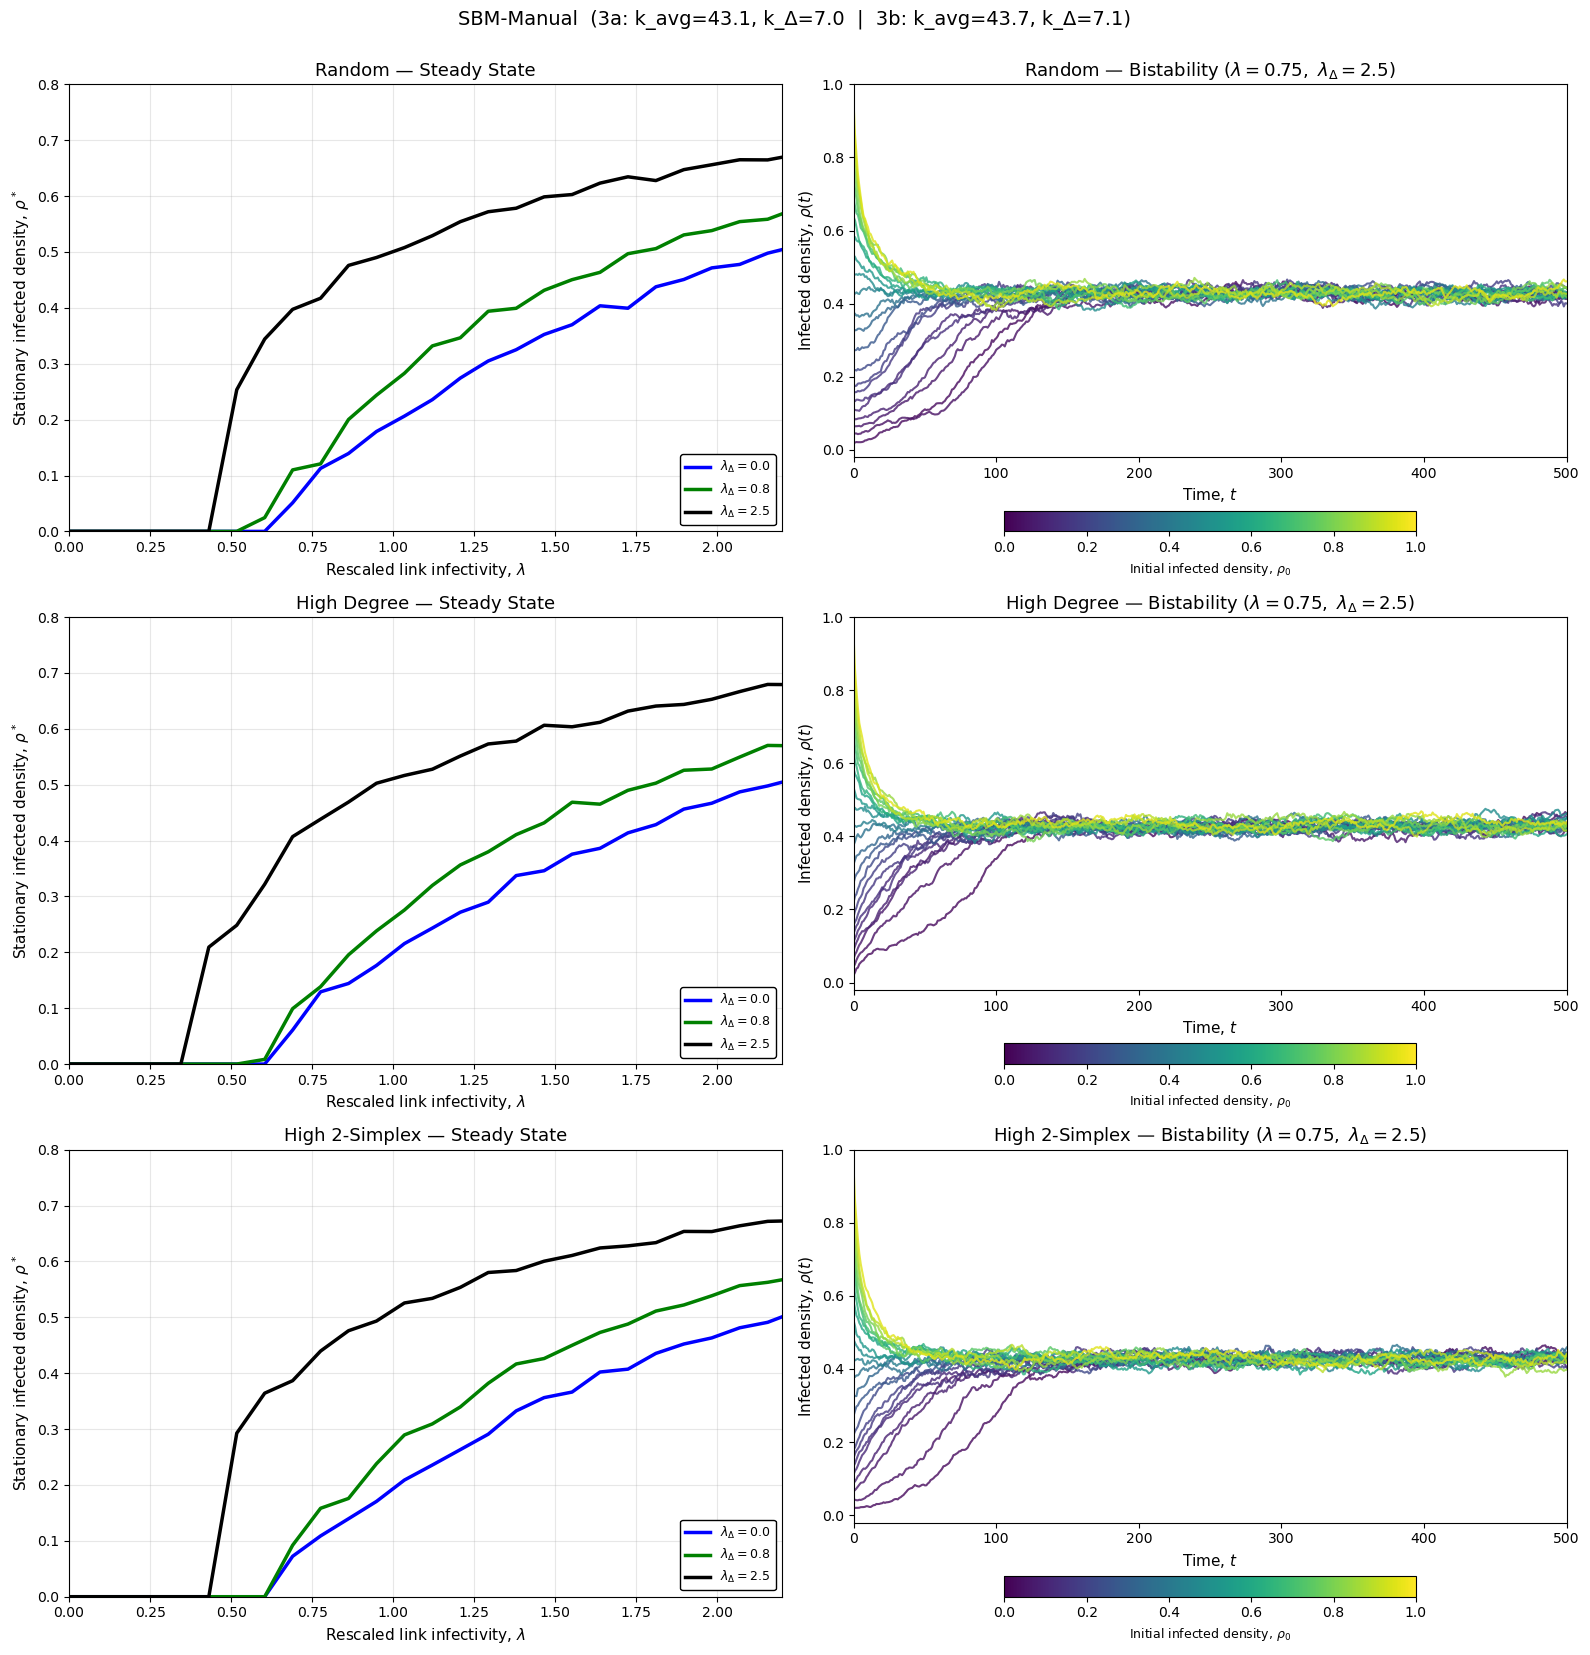

In [17]:
sim_colors = {0.0: 'blue', 0.8: 'green', 2.5: 'black'}
n_strats = len(STRATEGIES)

for config in TOPOLOGY_CONFIGS:
    name = config["name"]
    results = all_results[name]
    topo = topologies[name]
    k_avg_3a = topo["3a"]["k_avg"]
    k_d_avg_3a = topo["3a"]["k_d_avg"]
    k_avg_3b = topo["3b"]["k_avg"]
    k_d_avg_3b = topo["3b"]["k_d_avg"]

    fig, axes = plt.subplots(n_strats, 2, figsize=(16, 5.5 * n_strats))
    fig.suptitle(
        f"{name}  (3a: k_avg={k_avg_3a:.1f}, k_Δ={k_d_avg_3a:.1f}  "
        f"|  3b: k_avg={k_avg_3b:.1f}, k_Δ={k_d_avg_3b:.1f})",
        fontsize=14, y=1.00,
    )

    for row, (strat_name, _) in enumerate(STRATEGIES):
        res = results[strat_name]

        # --- Left column: steady-state rho* vs lambda ---
        ax_l = axes[row, 0]
        for ld in LAMBDA_DELTAS:
            ax_l.plot(
                LAMBDA_VALS, res['steady_state'][ld],
                color=sim_colors[ld], lw=2.5,
                label=rf'$\lambda_\Delta = {ld}$',
            )
        ax_l.set_xlim(0, 2.2)
        ax_l.set_ylim(0, 0.8)
        ax_l.set_xlabel(r'Rescaled link infectivity, $\lambda$', fontsize=11)
        ax_l.set_ylabel(r'Stationary infected density, $\rho^*$', fontsize=11)
        ax_l.set_title(f'{strat_name} — Steady State', fontsize=13)
        ax_l.legend(
            loc='lower right', framealpha=1, edgecolor='black', fontsize=9,
        )
        ax_l.grid(alpha=0.3)

        # --- Right column: bistability trajectories ---
        ax_r = axes[row, 1]
        norm = mcolors.Normalize(vmin=0, vmax=1)
        cmap = cm.viridis

        for rho_0, rho_history in res['trajectories']:
            ax_r.plot(
                range(len(rho_history)), rho_history,
                color=cmap(norm(rho_0)), alpha=0.8, lw=1.5,
            )
        ax_r.set_xlim(0, T_MAX_3B)
        ax_r.set_ylim(-0.02, 1.0)
        ax_r.set_xlabel('Time, $t$', fontsize=11)
        ax_r.set_ylabel(r'Infected density, $\rho(t)$', fontsize=11)
        ax_r.set_title(
            f'{strat_name} — Bistability '
            rf'($\lambda={LAM_3B},\ \lambda_\Delta={LAM_D_3B}$)',
            fontsize=13,
        )

        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(
            sm, ax=ax_r, orientation='horizontal',
            fraction=0.046, pad=0.12,
        )
        cbar.set_label(r'Initial infected density, $\rho_0$', fontsize=9)

    plt.tight_layout()
    out_path = f'../figures/seeding_strategy_comparison_{name.lower()}.png'
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    print(f'Saved: {out_path}')
    plt.show()

Maybe we make a visualization of rescaled infectivity on the x axis and actual threshold for bistability on the y. the  we plot each seeding strategy